# Image Preprocessing Pipeline

This notebook implements the preprocessing pipeline for dermoscopic images.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import json
from tqdm import tqdm

In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed" / "classification"
RESULTS_DIR = PROJECT_ROOT / "results"

IMAGES_DIR_SEGMENTATION = RAW_DATA_DIR / "segmentation" / "ISIC_2019_Training_Input"
IMAGES_DIR_CLASSIFICATION = RAW_DATA_DIR / "classification" / "ISIC2019_Training_Input"
LABELS_PATH = RAW_DATA_DIR / "classification" / "ISIC_2019_Training_GroundTruth.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Target size for all images
TARGET_SIZE = (256, 256)

In [4]:
df = pd.read_csv(DATA_DIR / "labels_with_class.csv")
print(f"Total images: {len(df)}")

Total images: 10015


## 1. Bilinear Interpolation Resizing

Bilinear interpolation is chosen because it provides smooth results while being computationally efficient. It's well-suited for dermoscopic images where we want to preserve texture patterns without introducing harsh aliasing artifacts.

In [5]:
def resize_image(image, target_size=TARGET_SIZE):
    """Resize image to target size using bilinear interpolation."""
    return cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)

In [6]:
# Test resizing on a sample image
sample_path = list(IMAGES_DIR_CLASSIFICATION.glob("*.jpg"))[0]
sample_img = cv2.imread(str(sample_path))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

print(f"Original shape: {sample_img.shape}")

Original shape: (450, 600, 3)


In [7]:
resized = resize_image(sample_rgb)
print(f"Resized shape: {resized.shape}")

Resized shape: (256, 256, 3)


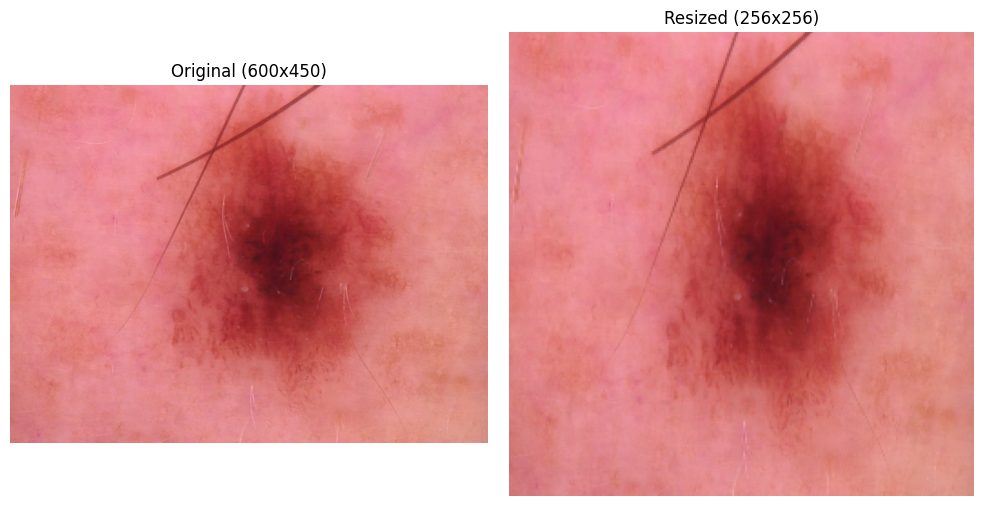

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title(f"Original ({sample_rgb.shape[1]}x{sample_rgb.shape[0]})")
axes[0].axis("off")

axes[1].imshow(resized)
axes[1].set_title(f"Resized ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)

CLAHE addresses the variable illumination observed in Week 1 (brightness std of 29.13). We apply CLAHE to the L channel in LAB color space to normalize brightness while preserving color information.

In [9]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Apply CLAHE to the L channel in LAB color space."""
    # Convert BGR to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l)
    
    # Merge and convert back to BGR
    lab_clahe = cv2.merge([l_clahe, a, b])
    result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    
    return result

In [10]:
# Test CLAHE on the sample image
sample_bgr = cv2.imread(str(sample_path))
clahe_result = apply_clahe(sample_bgr)

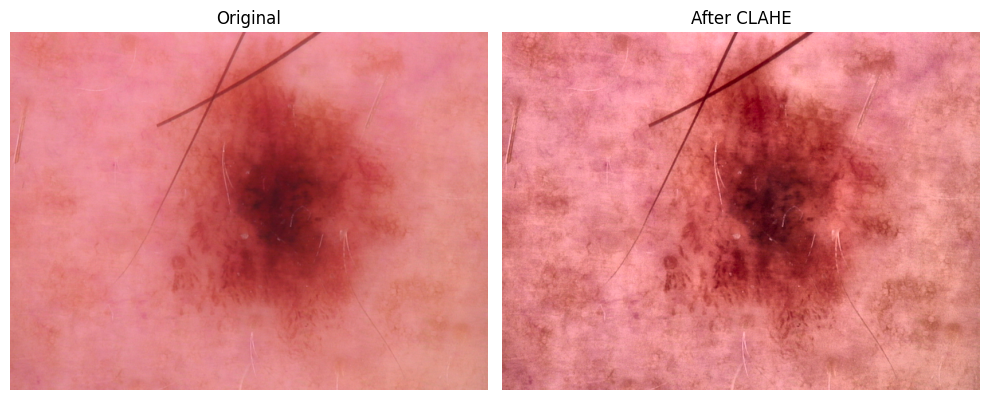

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[1].set_title("After CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

CLAHE enhances local contrast, making lesion features more visible while avoiding over-amplification of noise due to the clip limit.

## 3. Hair Removal

Week 1 analysis showed 88% of images have potential hair artifacts. We use morphological blackhat filtering to detect dark hair strands, then inpainting to fill them.

In [12]:
def remove_hair(image, kernel_size=17, threshold=10, inpaint_radius=1):
    """Remove hair artifacts using blackhat filtering and inpainting."""
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Create kernel for blackhat operation
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    
    # Blackhat filtering to detect dark hair-like structures
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    
    # Threshold to create hair mask
    _, hair_mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)
    
    # Inpaint to remove hair
    result = cv2.inpaint(image, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)
    
    return result, hair_mask

In [13]:
# Find an image with visible hair for demonstration
# Test on a few samples to find one with hair
image_files = list(IMAGES_DIR_CLASSIFICATION.glob("*.jpg"))[:20]
best_hair_img = None
best_hair_mask = None
max_hair_pixels = 0

for img_path in image_files:
    img = cv2.imread(str(img_path))
    _, mask = remove_hair(img)
    hair_pixels = np.sum(mask > 0)
    if hair_pixels > max_hair_pixels:
        max_hair_pixels = hair_pixels
        best_hair_img = img
        best_hair_mask = mask

print(f"Found image with {max_hair_pixels} hair pixels")

Found image with 117158 hair pixels


In [14]:
hair_removed, hair_mask = remove_hair(best_hair_img)

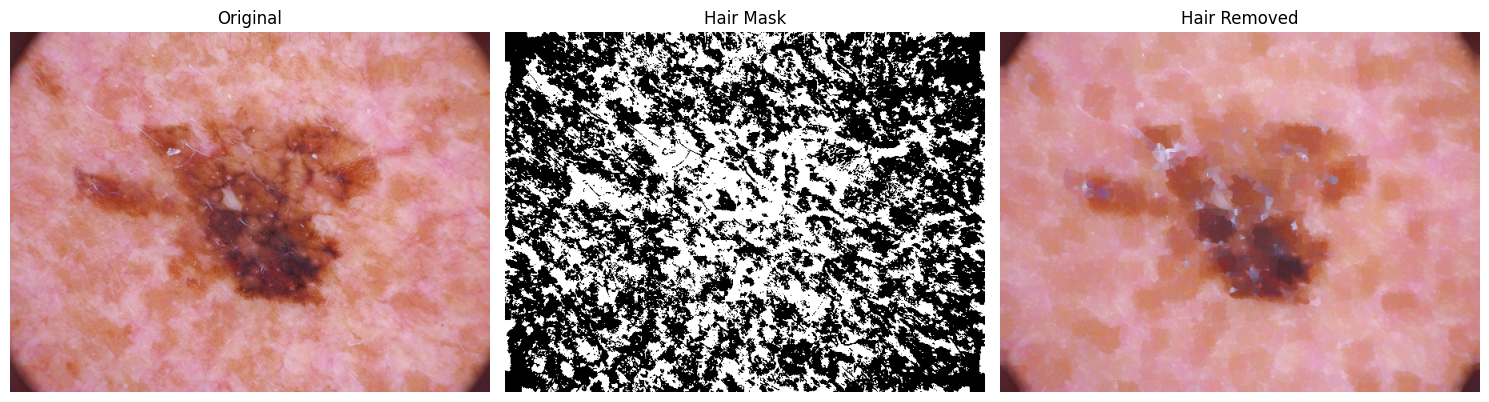

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(best_hair_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(hair_mask, cmap="gray")
axes[1].set_title("Hair Mask")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(hair_removed, cv2.COLOR_BGR2RGB))
axes[2].set_title("Hair Removed")
axes[2].axis("off")

plt.tight_layout()
plt.show()

The blackhat filter detects elongated dark structures (hair), and inpainting replaces them with surrounding pixel values using the Telea algorithm.

## 4. Complete Preprocessing Pipeline

In [16]:
def preprocess_image(image_path, target_size=TARGET_SIZE):
    """Complete preprocessing: resize, CLAHE, hair removal."""
    # Read image
    image = cv2.imread(str(image_path))
    if image is None:
        return None
    
    # Step 1: Resize
    image = resize_image(image, target_size)
    
    # Step 2: Hair removal (before CLAHE to avoid enhancing artifacts)
    image, _ = remove_hair(image)
    
    # Step 3: CLAHE
    image = apply_clahe(image)
    
    return image

In [17]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
import cv2


def process_single(row, images_dir, output_dir):
    img_name = row["image"]

    img_path = images_dir / f"{img_name}.jpg"

    if not img_path.exists():
        base_name = img_name.replace("_downsampled", "")
        img_path = images_dir / f"{base_name}.jpg"

    output_path = output_dir / f"{img_name}.jpg"

    try:
        if img_path.exists():
            processed = preprocess_image(img_path)

            if processed is not None:
                cv2.imwrite(str(output_path), processed)
                return ("success", img_name)

        return ("failed", img_name)

    except Exception:
        return ("failed", img_name)

In [18]:
# Test complete pipeline
preprocessed = preprocess_image(sample_path)
print(f"Preprocessed shape: {preprocessed.shape}")

Preprocessed shape: (256, 256, 3)


## 5. Visualization: Before vs After Pipeline

In [19]:
# Select diverse samples for visualization
np.random.seed(42)
sample_indices = np.random.choice(len(df), size=6, replace=False)
sample_images = df.iloc[sample_indices]["image"].values

The preprocessing pipeline standardizes all images to 256x256, removes hair artifacts, and normalizes illumination for more consistent model training.

## 6. Process and Save All Images


In [20]:
from tqdm import tqdm
import multiprocessing


def process_and_save_all(df, images_dir, output_dir):

    output_dir.mkdir(parents=True, exist_ok=True)

    successful = 0
    failed = []

    rows = df.to_dict("records")

    workers = multiprocessing.cpu_count()

    with ProcessPoolExecutor(max_workers=workers) as executor:

        futures = [
            executor.submit(process_single, row, images_dir, output_dir)
            for row in rows
        ]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):

            status, img_name = future.result()

            if status == "success":
                successful += 1
            else:
                failed.append(img_name)

    return successful, failed

In [22]:
# Process all images
successful, failed = process_and_save_all(df, IMAGES_DIR_CLASSIFICATION, PROCESSED_DIR)

Processing: 100%|██████████| 10015/10015 [00:40<00:00, 246.39it/s]


In [23]:
print(f"Successfully processed: {successful}")
print(f"Failed: {len(failed)}")

Successfully processed: 10015
Failed: 0


In [24]:
# Verify output
processed_files = list(PROCESSED_DIR.glob("*.jpg"))
print(f"Files in processed directory: {len(processed_files)}")

Files in processed directory: 10015


## 7. Save Preprocessing Summary

In [25]:
preprocessing_summary = {
    "target_size": list(TARGET_SIZE),
    "steps": ["bilinear_resize", "hair_removal", "clahe"],
    "clahe_params": {
        "clip_limit": 2.0,
        "tile_grid_size": [8, 8]
    },
    "hair_removal_params": {
        "kernel_size": 17,
        "threshold": 10,
        "inpaint_radius": 1
    },
    "total_images": len(df),
    "successfully_processed": successful,
    "failed": len(failed),
    "output_directory": str(PROCESSED_DIR)
}

with open(RESULTS_DIR / "preprocessing_summary.json", "w") as f:
    json.dump(preprocessing_summary, f, indent=2)

print("Preprocessing summary saved.")

Preprocessing summary saved.
